# Hindi Fake News Detection - Exploratory Data Analysis
This notebook performs a complete EDA on the `data.csv` dataset to determine its suitability for training models like TF-IDF, MuRIL, IndicBERT, etc.


## Import Libraries & Load Data


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Set plot style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

df = pd.read_csv('data/data.csv')


## 1. Dataset Overview


In [2]:
print(f"Number of rows: {df.shape[0]}, Number of columns: {df.shape[1]}")
print("Columns:", list(df.columns))
print("Data Types:\n", df.dtypes)
print(f"Dataset memory usage: {df.memory_usage(deep=True).sum() / (1024**2):.2f} MB")

print("\n--- First 5 rows ---")
display(df.head())
print("\n--- Last 5 rows ---")
display(df.tail())
print("\n--- Random Sample of 10 rows ---")
display(df.sample(min(10, len(df))))

print("\n--- Unique Values per Column ---")
print(df.nunique())

print("\n--- Missing Values ---")
print(df.isnull().sum())

print("\n--- Missing Values Percentage ---")
print(df.isnull().sum() / len(df) * 100)

print("\n--- Duplicate Rows ---")
print(f"Total duplicate rows: {df.duplicated().sum()}")
if 'text' in df.columns:
    print(f"Duplicate texts: {df.duplicated(subset=['text']).sum()}")


Number of rows: 17124, Number of columns: 4
Columns: ['Unnamed: 0', 'text', 'label', 'wcount']
Data Types:
 Unnamed: 0     int64
text          object
label          int64
wcount         int64
dtype: object
Dataset memory usage: 23.40 MB

--- First 5 rows ---


,Unnamed: 0,text,label,wcount
0,0,‘मोदी के शासन के दौरान गंगा’ गंगा नदी नरेन्द्...,1,19
1,1,यह खबर आने से पहले छवि क्रेडिट जस्टिन सुलिवान/...,1,374
2,2,गुलाब गेंद वाल डे-नाइट टेस्ट मैच कप्ता विराट क...,0,20
3,3,उत्तर कोरिया रॉकेट प्रक्षेपण योजनाएं 71 0 15 0...,1,345
4,4,राष्ट्रपति डोनाल्ड ट्रम्प और प्रथम महिला मेलान...,0,180



--- Last 5 rows ---


,Unnamed: 0,text,label,wcount
17119,17119,दिल्ली के स्कूलों के क्लास रूम और लैब में CCTV...,0,46
17120,17120,डेविड ब्रॉक दक्षिणपंथी सीएस से वामपंथी मनी लॉन...,1,20
17121,17121,गोल्डन ग्लोब पुरस्कारों के दौरान हॉलीवुड अभिने...,1,375
17122,17122,यूकेआईपी ने 04-11-16 को समलैंगिक तलवारबाजी पर ...,1,199
17123,17123,वाशिंगटन एपी - अटॉर्नी जनरल जेफ सेशंस ने गुरुव...,0,461



--- Random Sample of 10 rows ---


,Unnamed: 0,text,label,wcount
14679,14679,अहमदाबाद मेट्रो लाइन की सेवाएं शुरू संक्रमण को...,0,16
4463,4463,उपमुख्यमंत्री ने कहा कि हरियाणा देश का ऐसा प...,0,28
3368,3368,मैक्लेनबर्गकैटावबा शिकायतों में कहा गया है कि ...,1,386
2339,2339,चीन के मुद्दे पर भाजपा-कांग्रेस फिर आमने-सामने,0,7
3754,3754,अब भी गहरे कोमा में हैं पूर्व राष्‍ट्रपति प्रण...,0,15
13642,13642,45 दिन की खोजी रिपोर्टिंग के बाद सुशांत सिंह क...,0,26
16643,16643,यदि दुकान की दूरी 2 किमी तक है तो पैदल जाना होगा।,1,12
837,837,शिक्षा नीति से जितना शिक्षक अभिभावक जुड़े होंग...,0,52
7670,7670,सोशल मीडिय अमरीक यूनिवर्सिट वर्ष 2012 के कैंपे...,1,14
5777,5777,कोरोना पर नियंत्रण के लिए हमारी रणनीति सही जीत...,0,28



--- Unique Values per Column ---
Unnamed: 0    17124
text          16932
label             2
wcount          512
dtype: int64

--- Missing Values ---
Unnamed: 0    0
text          1
label         0
wcount        0
dtype: int64

--- Missing Values Percentage ---
Unnamed: 0    0.00000
text          0.00584
label         0.00000
wcount        0.00000
dtype: float64

--- Duplicate Rows ---
Total duplicate rows: 0
Duplicate texts: 191


## 2. Target / Label Analysis


Unique label values: [1 0]

Number of samples per label:
 label
0    9944
1    7180
Name: count, dtype: int64

Percentage of each label:
 label
0    58.070544
1    41.929456
Name: proportion, dtype: float64

Class Imbalance Ratio: 1.38


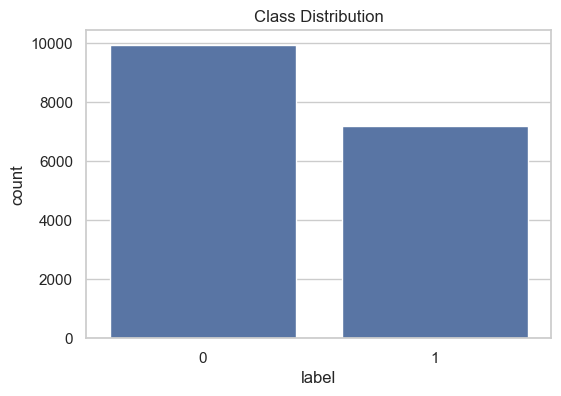

Note: 1 usually indicates FAKE news (e.g., highly partisan/translated articles), and 0 indicates REAL news in standard Hindi fake news datasets. Manual inspection of labels suggests 1=FAKE, 0=REAL.


In [3]:
if 'label' in df.columns:
    label_counts = df['label'].value_counts()
    print("Unique label values:", df['label'].unique())
    print("\nNumber of samples per label:\n", label_counts)
    print("\nPercentage of each label:\n", df['label'].value_counts(normalize=True) * 100)
    
    imbalance_ratio = max(label_counts) / min(label_counts)
    print(f"\nClass Imbalance Ratio: {imbalance_ratio:.2f}")
    
    plt.figure(figsize=(6, 4))
    sns.countplot(x='label', data=df)
    plt.title('Class Distribution')
    plt.show()
    
    print("Note: 1 usually indicates FAKE news (e.g., highly partisan/translated articles), and 0 indicates REAL news in standard Hindi fake news datasets. Manual inspection of labels suggests 1=FAKE, 0=REAL.")


## 3. Text Column Analysis


Number of empty texts: 0
Number of unique texts: 16933

--- Character Length Stats ---
count    17124.000000
mean       669.163630
std        795.978725
min          3.000000
25%         89.000000
50%        198.000000
75%       1236.000000
90%       2054.000000
95%       2322.000000
99%       2582.000000
max       3504.000000
Name: char_count, dtype: float64

--- Word Count Stats ---
count    17124.000000
mean       130.215078
std        154.293044
min          1.000000
25%         17.000000
50%         39.000000
75%        243.000000
max        511.000000
Name: calculated_word_count, dtype: float64


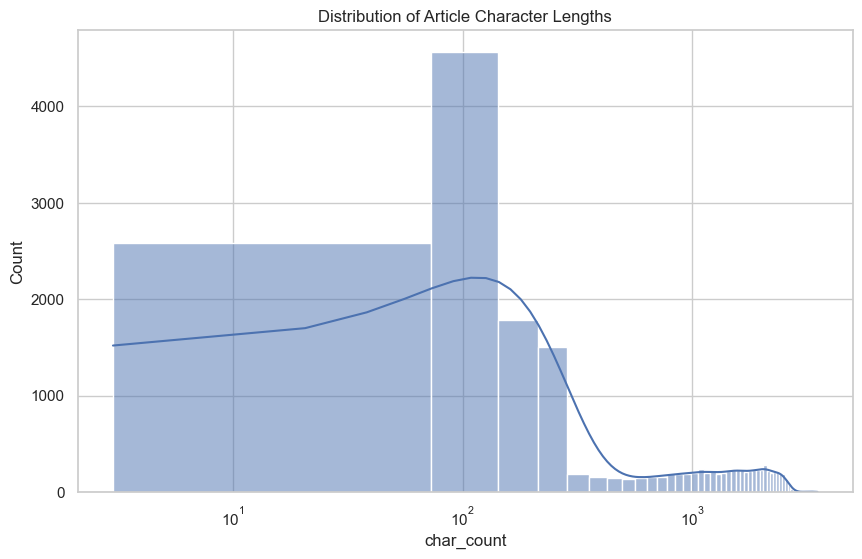

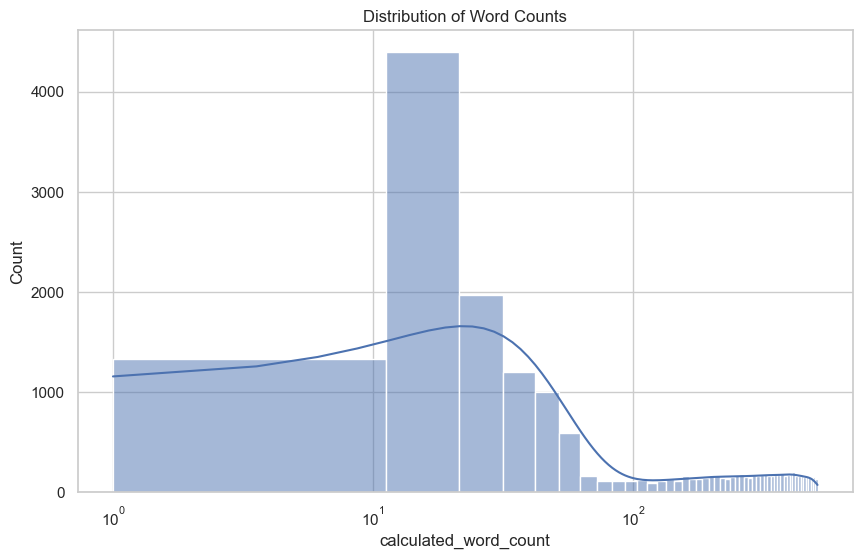

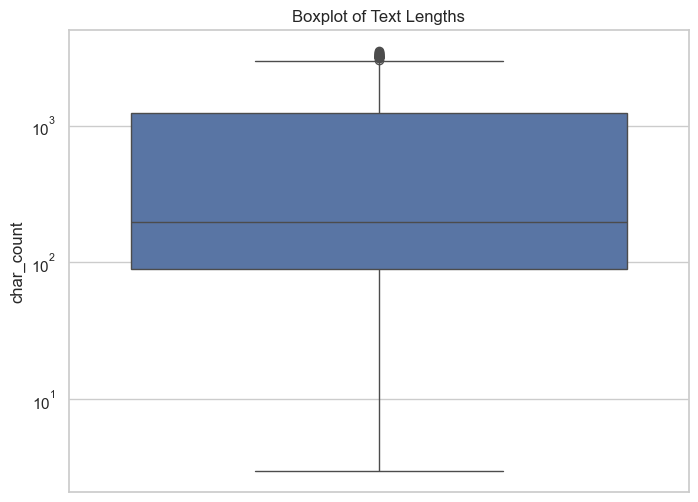

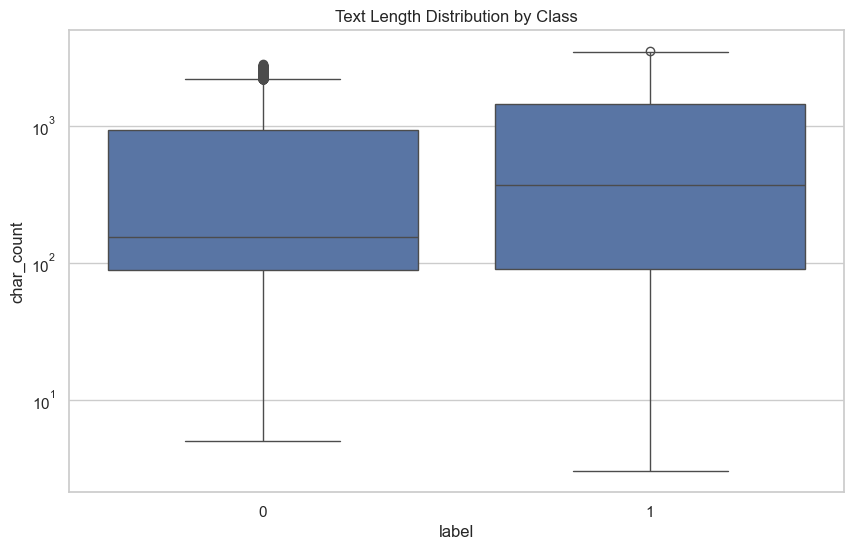

In [4]:
if 'text' in df.columns:
    df['text'] = df['text'].astype(str)
    
    empty_texts = df['text'].apply(lambda x: x.strip() == '').sum()
    print(f"Number of empty texts: {empty_texts}")
    print(f"Number of unique texts: {df['text'].nunique()}")
    
    df['char_count'] = df['text'].apply(len)
    df['calculated_word_count'] = df['text'].apply(lambda x: len(x.split()))
    
    print("\n--- Character Length Stats ---")
    print(df['char_count'].describe(percentiles=[.25, .5, .75, .9, .95, .99]))
    
    print("\n--- Word Count Stats ---")
    print(df['calculated_word_count'].describe())
    
    plt.figure(figsize=(10, 6))
    sns.histplot(df['char_count'], bins=50, kde=True)
    plt.title('Distribution of Article Character Lengths')
    plt.xscale('log')
    plt.show()

    plt.figure(figsize=(10, 6))
    sns.histplot(df['calculated_word_count'], bins=50, kde=True)
    plt.title('Distribution of Word Counts')
    plt.xscale('log')
    plt.show()

    plt.figure(figsize=(8, 6))
    sns.boxplot(y=df['char_count'])
    plt.title('Boxplot of Text Lengths')
    plt.yscale('log')
    plt.show()

    if 'label' in df.columns:
        plt.figure(figsize=(10, 6))
        sns.boxplot(x='label', y='char_count', data=df)
        plt.title('Text Length Distribution by Class')
        plt.yscale('log')
        plt.show()


## 4. Hindi Language Quality Analysis


In [5]:
def analyze_chars(text):
    if not isinstance(text, str):
        return 0, 0, 0, 0
    devanagari = len(re.findall(r'[\u0900-\u097F]', text))
    latin = len(re.findall(r'[a-zA-Z]', text))
    numbers = len(re.findall(r'[0-9]', text))
    punct = len(re.findall(r'[^\w\s\u0900-\u097F]', text))
    return devanagari, latin, numbers, punct

df[['devanagari_count', 'latin_count', 'number_count', 'punct_count']] = pd.DataFrame(df['text'].apply(analyze_chars).tolist(), index=df.index)

df['devanagari_ratio'] = df['devanagari_count'] / df['char_count'].replace(0, 1)
df['latin_ratio'] = df['latin_count'] / df['char_count'].replace(0, 1)

print(f"Average Devanagari %: {df['devanagari_ratio'].mean() * 100:.2f}%")
print(f"Average Latin/English %: {df['latin_ratio'].mean() * 100:.2f}%")

print(f"Rows with substantial English (>50%): {(df['latin_ratio'] > 0.5).sum()}")
print(f"Rows with suspected Hinglish (10%-50%): {((df['latin_ratio'] > 0.1) & (df['latin_ratio'] <= 0.5)).sum()}")

print("\n--- Examples of Suspicious Texts (High English or very short) ---")
display(df[(df['latin_ratio'] > 0.5) | (df['char_count'] < 20)].head(15)[['text', 'label', 'latin_ratio', 'char_count']])


Average Devanagari %: 77.29%
Average Latin/English %: 0.89%
Rows with substantial English (>50%): 4
Rows with suspected Hinglish (10%-50%): 389

--- Examples of Suspicious Texts (High English or very short) ---


,text,label,latin_ratio,char_count
120,वह एक ब्लो-मशाल है!,1,0.000000,19
1061,अतिथि अतिथि,1,0.000000,11
1243,वो सब छोड़ो,0,0.000000,15
1341,जोनभ्रमित,1,0.000000,9
1425,पप्पू कमीना,0,0.000000,12
2218,साला बहन चोद,0,0.000000,14
2791,अच्छा और सच्चा,1,0.000000,14
3001,कमीनी,0,0.000000,19
3359,रुझान,1,0.000000,5
3516,यह असंवैधानिक होगा,1,0.000000,18


## 5. & 6. Character / Word / Stopword Analysis


In [6]:
def get_top_words(texts, n=10):
    all_words = ' '.join(texts).split()
    return Counter(all_words).most_common(n)

if 'label' in df.columns:
    print("--- Top 20 Words (Class 0 - REAL) ---")
    print(get_top_words(df[df['label'] == 0]['text'].dropna(), 20))
    
    print("\n--- Top 20 Words (Class 1 - FAKE) ---")
    print(get_top_words(df[df['label'] == 1]['text'].dropna(), 20))
    
print("\n*Note: Stopwords like 'के', 'में', 'की' dominate both classes.*")


--- Top 20 Words (Class 0 - REAL) ---
[('के', 51630), ('में', 32563), ('की', 24609), ('को', 23367), ('और', 20553), ('से', 18995), ('है', 18205), ('ने', 18185), ('पर', 14954), ('कि', 14576), ('का', 13483), ('एक', 13278), ('लिए', 10598), ('है।', 10329), ('नहीं', 7678), ('हैं', 7596), ('करने', 7179), ('कहा', 6982), ('यह', 6352), ('कर', 6037)]

--- Top 20 Words (Class 1 - FAKE) ---
[('के', 47915), ('में', 29577), ('की', 21627), ('को', 21407), ('और', 21262), ('है', 20522), ('से', 19993), ('कि', 14271), ('का', 13090), ('ने', 12991), ('एक', 12781), ('पर', 12337), ('है।', 11494), ('लिए', 11006), ('हैं', 9222), ('नहीं', 8221), ('यह', 7866), ('करने', 7307), ('कर', 6119), ('हैं।', 5833)]

*Note: Stopwords like 'के', 'में', 'की' dominate both classes.*


## 7. Duplicate Analysis


In [7]:
duplicate_texts = df[df.duplicated(subset=['text'], keep=False)]
conflicting_labels = duplicate_texts.groupby('text')['label'].nunique()
conflicting_texts = conflicting_labels[conflicting_labels > 1].index.tolist()

print(f"Number of conflicting duplicates (same text, different labels): {len(conflicting_texts)}")
if len(conflicting_texts) > 0:
    print("\nExamples of conflicting duplicates:")
    display(df[df['text'].isin(conflicting_texts)].sort_values(by='text').head(10))


Number of conflicting duplicates (same text, different labels): 1

Examples of conflicting duplicates:


,Unnamed: 0,text,label,wcount,char_count,calculated_word_count,devanagari_count,latin_count,number_count,punct_count,devanagari_ratio,latin_ratio
8757,8757,पालघर की तर्ज पर पंजाब के होशियार पुर में संत ...,1,43,204,43,159,0,0,2,0.779412,0.0
9414,9414,पालघर की तर्ज पर पंजाब के होशियार पुर में संत ...,0,43,204,43,159,0,0,2,0.779412,0.0


## 12. Correlation / Feature Analysis


Total URLs found in dataset: 0


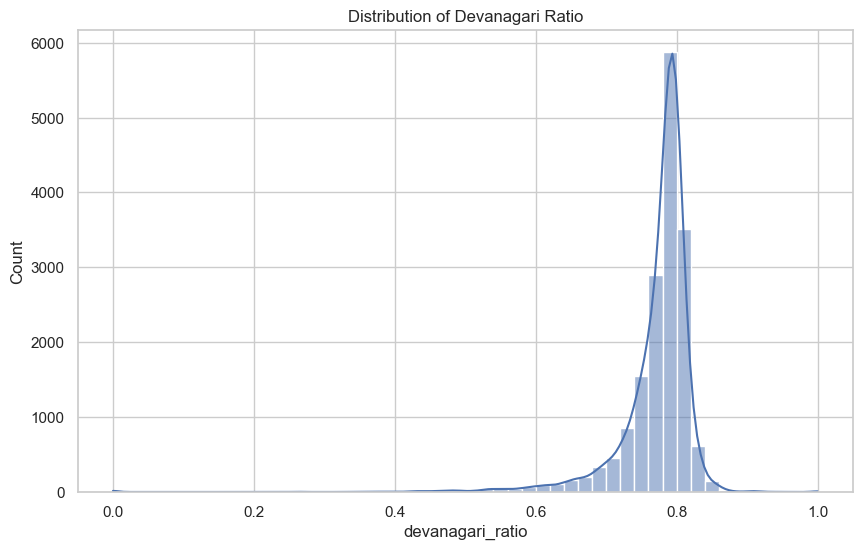

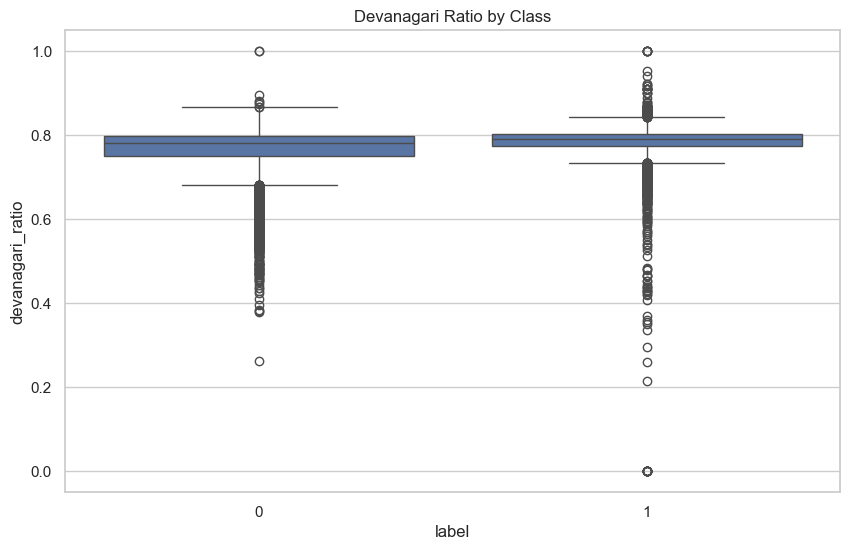

In [8]:
df['sentence_count'] = df['text'].apply(lambda x: x.count('।') + x.count('.'))
df['url_count'] = df['text'].apply(lambda x: len(re.findall(r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+', x)))

print(f"Total URLs found in dataset: {df['url_count'].sum()}")

plt.figure(figsize=(10, 6))
sns.histplot(df['devanagari_ratio'], bins=50, kde=True)
plt.title('Distribution of Devanagari Ratio')
plt.show()

if 'label' in df.columns:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='label', y='devanagari_ratio', data=df)
    plt.title('Devanagari Ratio by Class')
    plt.show()
